This notebook includes runs related to unmixing by using:

1. A very simple CNN, of various different channel sizes. These sizes for hidden channels, kernels, and modes are:
    - [8], [4, 4], [3, 3] 
    - [16, 16], [8, 8, 8], [3, 3, 3] 
    - [32, 32, 32], [16, 16, 16, 16], [3, 3, 3, 3] 
    - [64, 64, 64, 64], [32, 32, 32, 32, 32], [3, 3, 3, 3, 3] 
    - [128, 128, 128, 128, 128], [64, 64, 64, 64, 64, 64], [3, 3, 3, 3, 3, 3] 
2. P, Q, final projection networks as follows:
    - For P:
        - in_ch=1
        - out_ch=8
        - hidden_ch=[2, 4]
    - For Q:
        - in_ch=8
        - out_ch=1
        - hidden_ch=[4, 2]
    - For final projection:
        - Linear[81, 64]
        - GELU
        - Linear[64, 3]
3. Of varying learning rates fine tuned for the given model.
4. With dropout, optimized using AdamW.
5. A loss of simple MSE, with a small additional terms for sum of residuals.
6. With a training loop that loops over the entire training dataset at each epoch, with a max epochs of 80.
7. Data separated into 1500 training samples, 100 static validation samples, and 123 static test samples.
8. Trained using a GPU.
9. Statistically normalized datasets.
10. GELU as the activation function throughout.

### Imports, data, model initialization, and various other setups

In [1]:
# Set up autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Sys Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[3]
sys.path.append(str(github_root))

In [11]:
# Self-def imports

from src.dl.data import get_data
from src.dl.models.fno.FNO import FNO_nD
from src.dl.train import train_model

In [4]:
# Package imports
import torch
import torch.nn as nn

In [5]:
# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
# Data hyperparams
save_path = rf"{github_root}\data\simpler_data_rwc.csv"

batch_size = 32
epoch = 80
n_tb_epoch = 47

In [ ]:
# Define model configs

cfg_p = {
    'in_channels': 1, 
    'out_channels': 128, 
    'hidden_channels': [8, 32], 
    'dropout': 0.05,
    'act_fn': 'gelu'
}

cfg_q = {
    'in_channels': 128, 
    'out_channels': 32, 
    'hidden_channels': [128, 64], 
    'dropout': 0.05,
    'act_fn': 'gelu'
}



models_list = [
    {
        'fb_hidden_channels': [8], 'fb_modes': [[4], [4]], 'fb_kernel': [3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q
    },
    {
        'fb_hidden_channels': [16,16], 'fb_modes': [[8], [8], [8]], 'fb_kernel': [3, 3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q
    },
    {
        'fb_hidden_channels': [32,32,32], 'fb_modes': [[16], [16], [16], [16]], 'fb_kernel': [3, 3, 3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q 
    },
    {
        'fb_hidden_channels': [64,64,64,64], 'fb_modes': [[32], [32], [32], [32], [32]], 'fb_kernel': [3, 3, 3, 3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q 
    },
    {
        'fb_hidden_channels': [128,128,128,128,128], 'fb_modes': [[40], [40], [40], [40], [40], [40]], 'fb_kernel': [3, 3, 3, 3, 3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q 
    },
    {
        'fb_hidden_channels': [256,256,256,256,256,256], 'fb_modes': [[40], [40], [40], [40], [40], [40], [40]], 'fb_kernel': [3, 3, 3, 3, 3, 3,3], 'cfg_p': cfg_p, 'cfg_q': cfg_q
    }
]

lr_list = [1e-3, 2.5e-3, 5e-3, 8e-4, 3e-4]

dir_list = [
    'fno_8',
    'fno_16',
    'fno_32',
    'fno_64',
    'fno_128',
    'fno_256'
]

name_list = [
        'FNO_8',
        'FNO_16',
        'FNO_32',
        'FNO_64',
        'FNO_128',
        'FNO_256'
    ]

# Create dirs

for dir_name in dir_list:
    save_dir = github_root / 'runs' / 'dl' / 'simpler_data' / 'fno' / dir_name
    save_dir.mkdir(parents=True, exist_ok=True)

### Model train loop

Epoch 1/80, Step 1/47, Train Loss: 0.101305
Epoch 1/80, Step 2/47, Train Loss: 0.115099
Epoch 1/80, Step 3/47, Train Loss: 0.110524
Epoch 1/80, Step 4/47, Train Loss: 0.089327
Epoch 1/80, Step 5/47, Train Loss: 0.105813
Epoch 1/80, Step 6/47, Train Loss: 0.102857
Epoch 1/80, Step 7/47, Train Loss: 0.096092
Epoch 1/80, Step 8/47, Train Loss: 0.093392
Epoch 1/80, Step 9/47, Train Loss: 0.088785
Epoch 1/80, Step 10/47, Train Loss: 0.085478
Epoch 1/80, Step 11/47, Train Loss: 0.092438
Epoch 1/80, Step 12/47, Train Loss: 0.088085
Epoch 1/80, Step 13/47, Train Loss: 0.097419
Epoch 1/80, Step 14/47, Train Loss: 0.095986
Epoch 1/80, Step 15/47, Train Loss: 0.101435
Epoch 1/80, Step 16/47, Train Loss: 0.129531
Epoch 1/80, Step 17/47, Train Loss: 0.091631
Epoch 1/80, Step 18/47, Train Loss: 0.080600
Epoch 1/80, Step 19/47, Train Loss: 0.095967
Epoch 1/80, Step 20/47, Train Loss: 0.110510
Epoch 1/80, Step 21/47, Train Loss: 0.083897
Epoch 1/80, Step 22/47, Train Loss: 0.088952
Epoch 1/80, Step 23

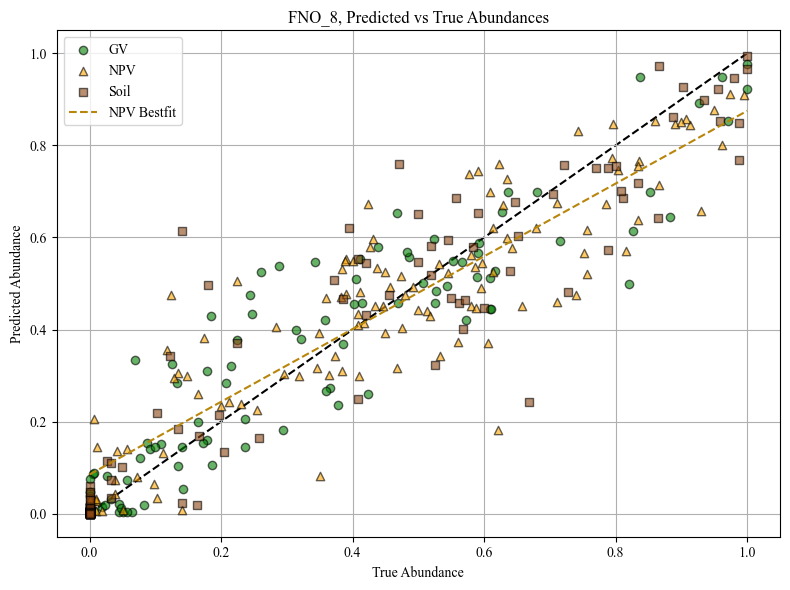

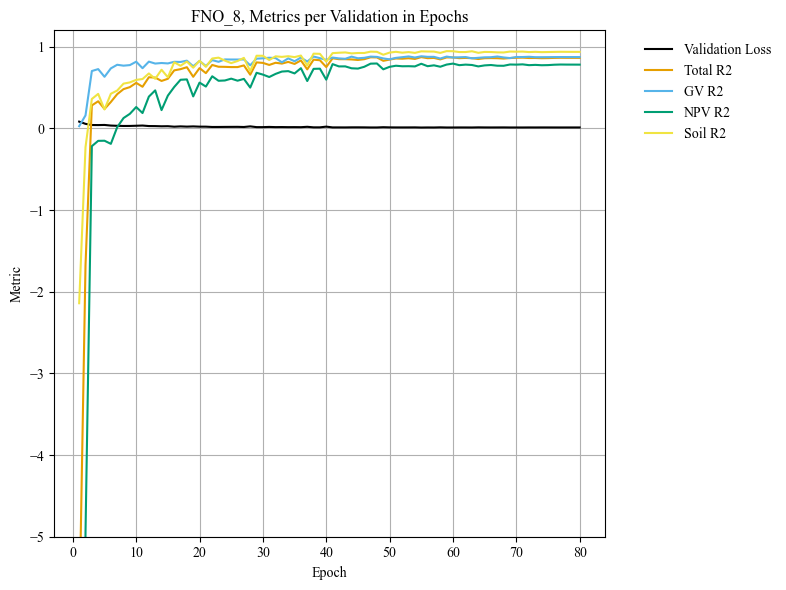

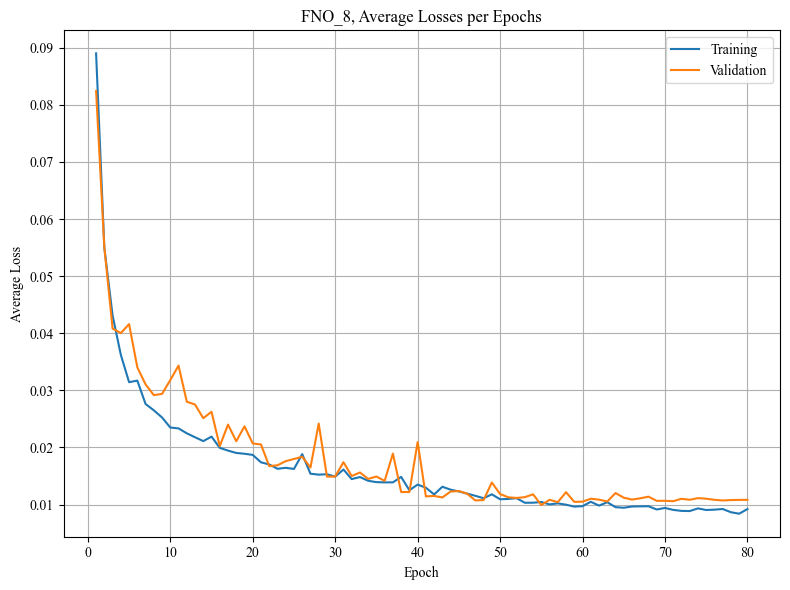

Testing complete
[[1.16539000e+05 1.70256800e+07 1.23001635e-02 8.34502399e-01
  8.67691875e-01 7.41626740e-01 8.94188523e-01 7.45596737e-02
  6.81084394e-02 9.50348750e-02 6.05357103e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.101592
Epoch 1/80, Step 2/47, Train Loss: 0.112754
Epoch 1/80, Step 3/47, Train Loss: 0.090216
Epoch 1/80, Step 4/47, Train Loss: 0.099358
Epoch 1/80, Step 5/47, Train Loss: 0.087213
Epoch 1/80, Step 6/47, Train Loss: 0.112012
Epoch 1/80, Step 7/47, Train Loss: 0.082934
Epoch 1/80, Step 8/47, Train Loss: 0.105990
Epoch 1/80, Step 9/47, Train Loss: 0.102108
Epoch 1/80, Step 10/47, Train Loss: 0.105051
Epoch 1/80, Step 11/47, Train Loss: 0.099695
Epoch 1/80, Step 12/47, Train Loss: 0.097192
Epoch 1/80, Step 13/47, Train Loss: 0.090980
Epoch 1/80, Step 14/47, Train Loss: 0.085233
Epoch 1/80, Step 15/47, Train Loss: 0.109267
Epoch 1/80, Step 16/47, Train Loss: 0.083629
Epoch 1/80, Step 17/47, Train Loss: 0.075279
Epoch 1/80, Step 18/47, Train Loss: 0.061587
Epoch 1/8

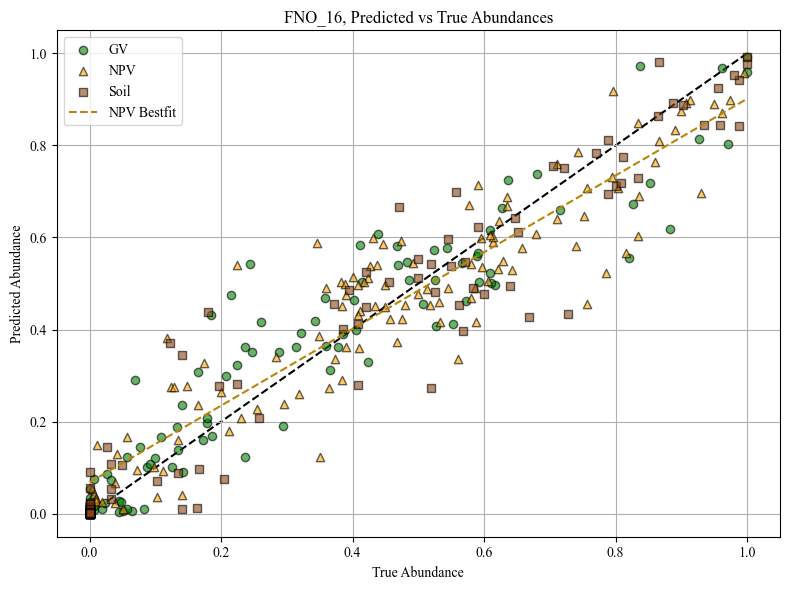

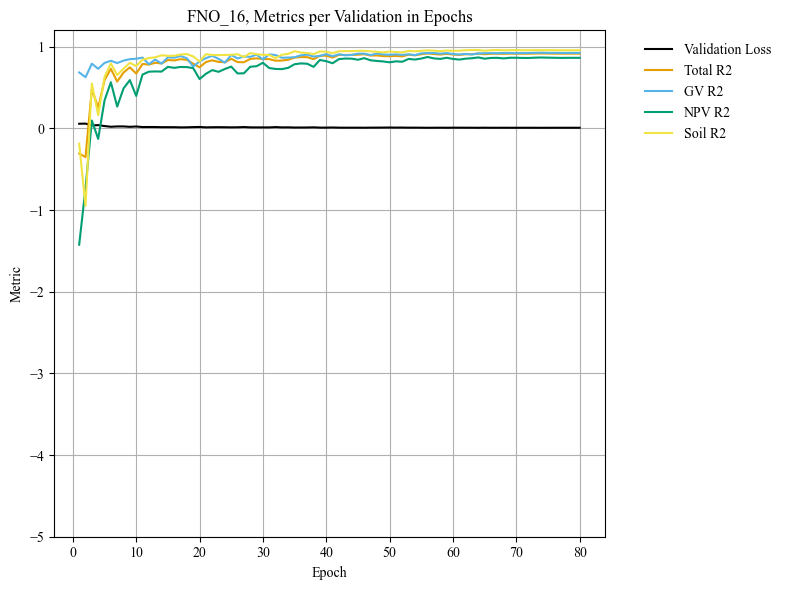

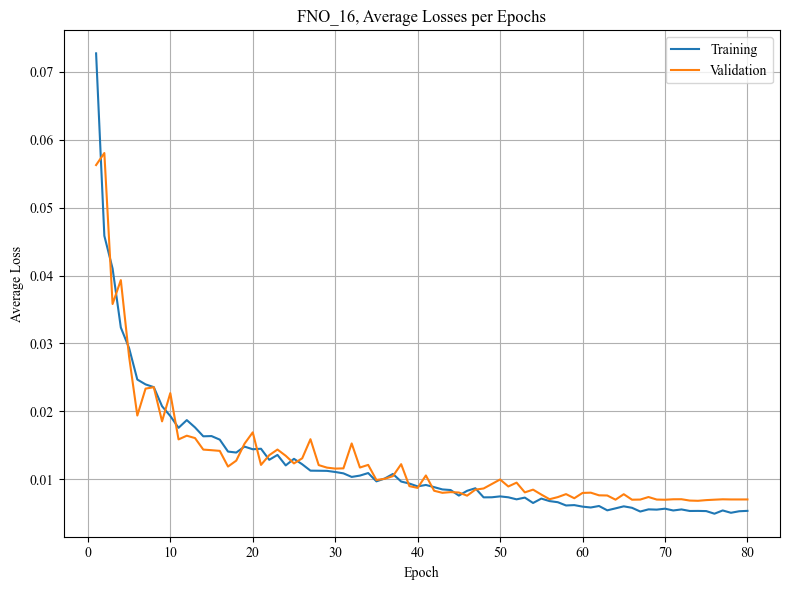

Testing complete
[[1.54019000e+05 1.88207520e+07 8.31546448e-03 8.88854265e-01
  8.97384286e-01 8.29050362e-01 9.40128028e-01 6.19838573e-02
  5.91276847e-02 7.98612982e-02 4.69625853e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.102687
Epoch 1/80, Step 2/47, Train Loss: 0.100015
Epoch 1/80, Step 3/47, Train Loss: 0.091374
Epoch 1/80, Step 4/47, Train Loss: 0.103020
Epoch 1/80, Step 5/47, Train Loss: 0.082178
Epoch 1/80, Step 6/47, Train Loss: 0.079114
Epoch 1/80, Step 7/47, Train Loss: 0.096587
Epoch 1/80, Step 8/47, Train Loss: 0.094533
Epoch 1/80, Step 9/47, Train Loss: 0.108877
Epoch 1/80, Step 10/47, Train Loss: 0.078598
Epoch 1/80, Step 11/47, Train Loss: 0.076177
Epoch 1/80, Step 12/47, Train Loss: 0.116425
Epoch 1/80, Step 13/47, Train Loss: 0.091791
Epoch 1/80, Step 14/47, Train Loss: 0.079571
Epoch 1/80, Step 15/47, Train Loss: 0.075028
Epoch 1/80, Step 16/47, Train Loss: 0.085092
Epoch 1/80, Step 17/47, Train Loss: 0.094216
Epoch 1/80, Step 18/47, Train Loss: 0.079686
Epoch 1/8

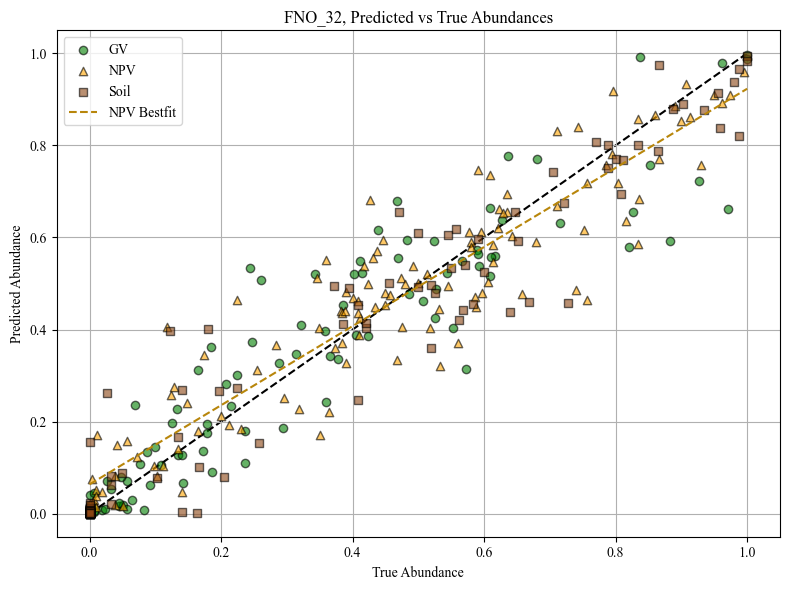

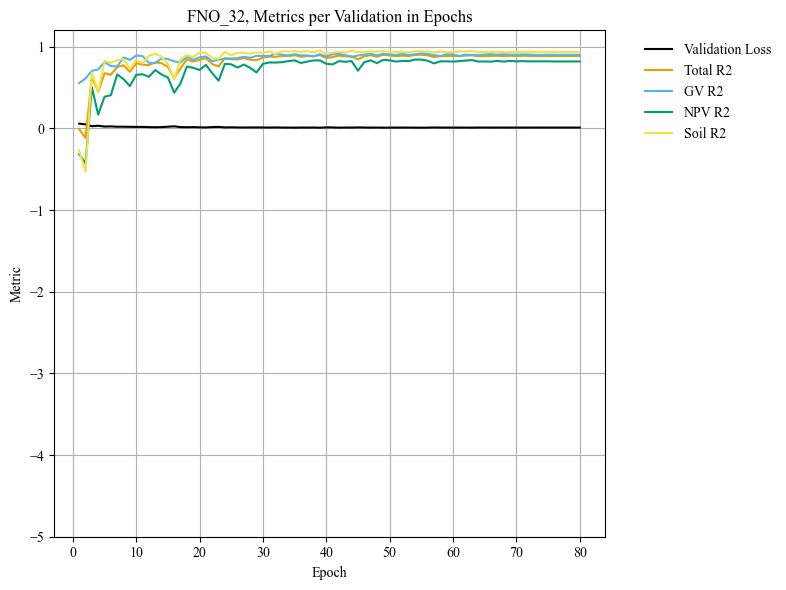

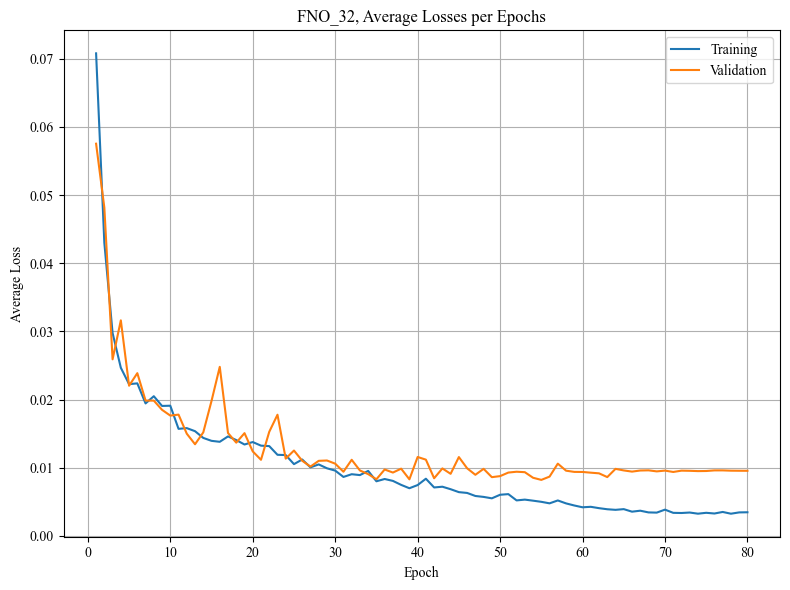

Testing complete
[[3.15315000e+05 2.42628000e+07 8.39850679e-03 8.91597927e-01
  8.86816621e-01 8.45813811e-01 9.42163229e-01 6.06003106e-02
  6.04424551e-02 7.57274777e-02 4.56309840e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.089232
Epoch 1/80, Step 2/47, Train Loss: 0.112961
Epoch 1/80, Step 3/47, Train Loss: 0.089557
Epoch 1/80, Step 4/47, Train Loss: 0.083696
Epoch 1/80, Step 5/47, Train Loss: 0.105236
Epoch 1/80, Step 6/47, Train Loss: 0.091292
Epoch 1/80, Step 7/47, Train Loss: 0.099521
Epoch 1/80, Step 8/47, Train Loss: 0.086408
Epoch 1/80, Step 9/47, Train Loss: 0.100831
Epoch 1/80, Step 10/47, Train Loss: 0.095155
Epoch 1/80, Step 11/47, Train Loss: 0.109262
Epoch 1/80, Step 12/47, Train Loss: 0.118968
Epoch 1/80, Step 13/47, Train Loss: 0.088848
Epoch 1/80, Step 14/47, Train Loss: 0.088602
Epoch 1/80, Step 15/47, Train Loss: 0.114824
Epoch 1/80, Step 16/47, Train Loss: 0.095035
Epoch 1/80, Step 17/47, Train Loss: 0.086564
Epoch 1/80, Step 18/47, Train Loss: 0.106779
Epoch 1/8

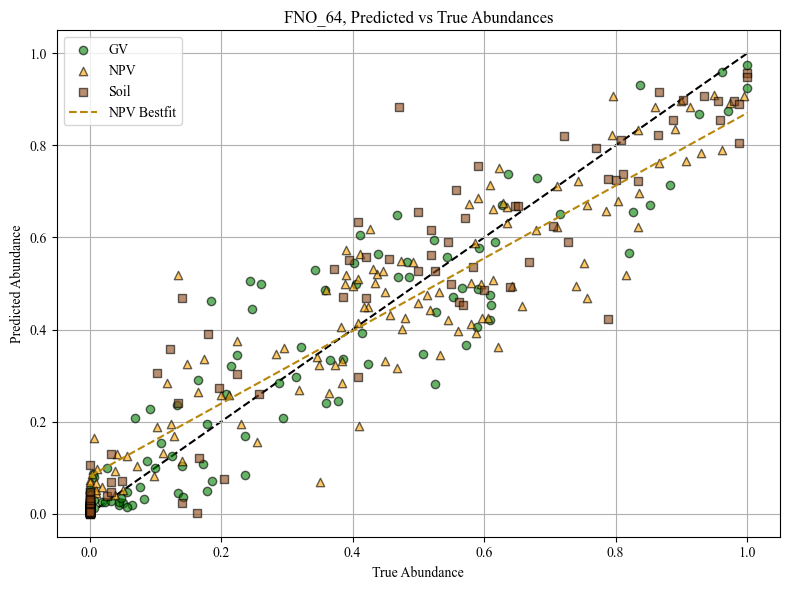

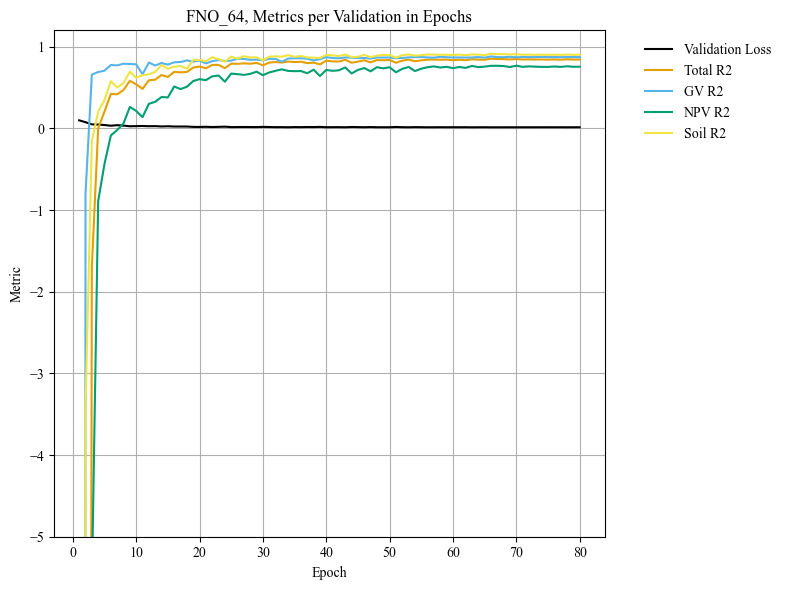

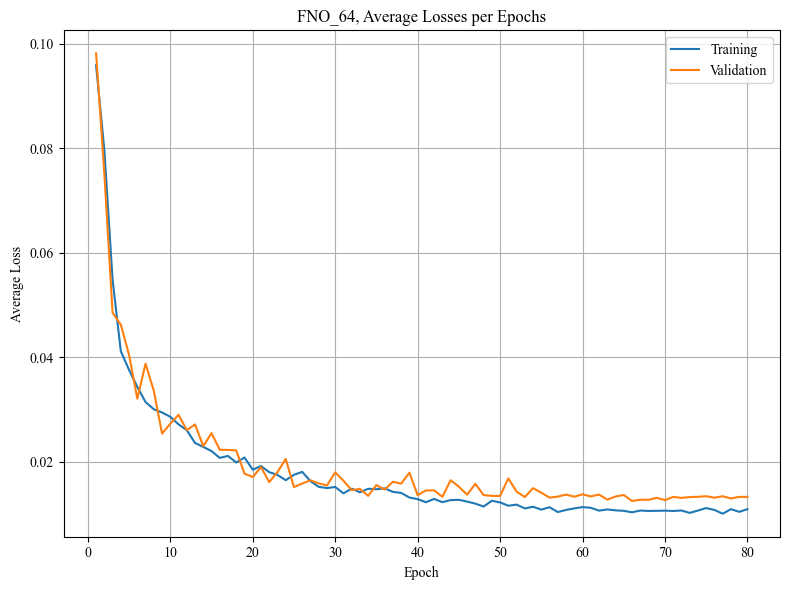

Testing complete
[[1.18638700e+06 4.46813600e+07 1.08886501e-02 8.50388229e-01
  8.68504405e-01 7.66687870e-01 9.15972352e-01 7.47171566e-02
  7.13255629e-02 9.35280100e-02 5.92978932e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.100368
Epoch 1/80, Step 2/47, Train Loss: 0.100411
Epoch 1/80, Step 3/47, Train Loss: 0.080361
Epoch 1/80, Step 4/47, Train Loss: 0.099841
Epoch 1/80, Step 5/47, Train Loss: 0.106545
Epoch 1/80, Step 6/47, Train Loss: 0.092866
Epoch 1/80, Step 7/47, Train Loss: 0.085274
Epoch 1/80, Step 8/47, Train Loss: 0.112426
Epoch 1/80, Step 9/47, Train Loss: 0.112503
Epoch 1/80, Step 10/47, Train Loss: 0.084164
Epoch 1/80, Step 11/47, Train Loss: 0.103546
Epoch 1/80, Step 12/47, Train Loss: 0.090100
Epoch 1/80, Step 13/47, Train Loss: 0.091509
Epoch 1/80, Step 14/47, Train Loss: 0.107609
Epoch 1/80, Step 15/47, Train Loss: 0.090492
Epoch 1/80, Step 16/47, Train Loss: 0.090375
Epoch 1/80, Step 17/47, Train Loss: 0.080972
Epoch 1/80, Step 18/47, Train Loss: 0.088856
Epoch 1/8

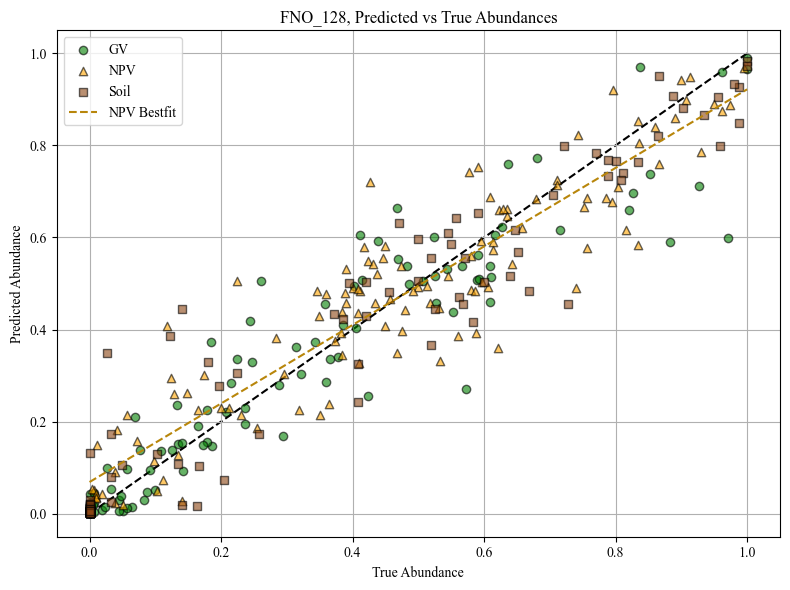

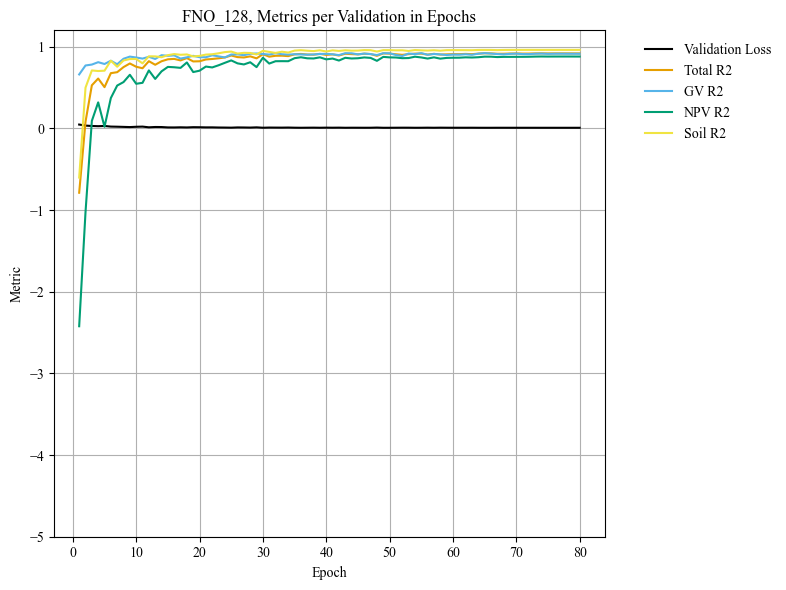

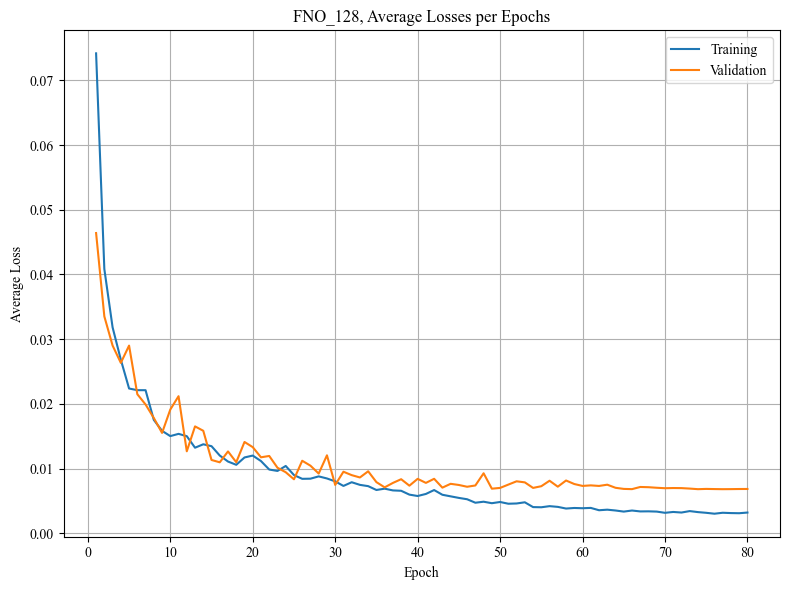

Testing complete
[[4.65704300e+06 1.24364944e+08 8.52127932e-03 8.88274014e-01
  8.92268121e-01 8.37596536e-01 9.34957504e-01 6.19897507e-02
  5.55698276e-02 7.97978491e-02 5.06015681e-02]]


In [14]:
fno_dict = {}

for i in range(len(models_list)):
    
    cfg_dict = models_list[i]
    lr = lr_list[i]
    save_dir = dir_list[i]
    model_name = name_list[i]

    dataloaders = get_data(save_path=save_path, spec_range=[900, 1700], batch_size=32)
    model = FNO_nD(**cfg_dict).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epoch*n_tb_epoch, eta_min=1e-6)
    loss = nn.MSELoss()

    model_dict = train_model(
        model=model,
        loss_fn=loss,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        configured_data=dataloaders,
        n_epoch=epoch,
        n_tb_epoch=n_tb_epoch,
        device=device,
        dtype=torch.float32,
        save_dir=save_dir,
        model_name=model_name
    )

    fno_dict[model_name] = model_dict
    print(fno_dict[model_name]['metrics_total'])